# 8.4 Stochastic Gradient Descent

This notebook explores **stochastic gradient descent (SGD)** — the workhorse optimizer for large-scale machine learning. We cover minibatch SGD, learning rate schedules, iterate averaging, and adaptive methods (AdaGrad, RMSProp, Adam).

## Real-World Scenario

A pharmaceutical company wants to predict **drug sensitivity** (IC50) from gene expression profiles of cancer cell lines. With thousands of cell lines and hundreds of gene features, full-batch gradient descent is impractical. We'll use this regression task as our running example to compare SGD variants and adaptive optimizers.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## 1. The Stochastic Optimization Problem

In many ML problems, the objective is an **average over training examples**:

$$\mathcal{L}(\boldsymbol{\theta}) = \frac{1}{N} \sum_{n=1}^{N} \ell(y_n, f(\mathbf{x}_n; \boldsymbol{\theta}))$$

This is called a **finite sum problem** (Eq. 8.55). The full gradient requires summing over all $N$ examples:

$$\mathbf{g}_t = \frac{1}{N} \sum_{n=1}^{N} \nabla_\theta \ell(y_n, f(\mathbf{x}_n; \boldsymbol{\theta}_t))$$

When $N$ is large, this is expensive. **SGD** approximates the gradient using a random **minibatch** $\mathcal{B}_t$ of $B \ll N$ examples:

$$\mathbf{g}_t \approx \frac{1}{|\mathcal{B}_t|} \sum_{n \in \mathcal{B}_t} \nabla_\theta \ell(y_n, f(\mathbf{x}_n; \boldsymbol{\theta}_t))$$

This is an **unbiased estimate** of the true gradient, so SGD converges — provided we decay the learning rate appropriately.

### The SGD Update

$$\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta_t \mathbf{g}_t$$

where $\eta_t$ is the step size (learning rate) at iteration $t$.

### Our Test Problem: Linear Regression

We start with a simple 2D problem to build intuition. For linear regression, the loss is:

$$\mathcal{L}(\boldsymbol{\theta}) = \frac{1}{2N} \sum_{n=1}^{N} (\mathbf{x}_n^\top \boldsymbol{\theta} - y_n)^2 = \frac{1}{2N} \|X\boldsymbol{\theta} - \mathbf{y}\|^2$$

The per-example gradient is:

$$\nabla_\theta \ell_n(\boldsymbol{\theta}_t) = (\boldsymbol{\theta}_t^\top \mathbf{x}_n - y_n) \mathbf{x}_n$$

With minibatch size $B = 1$, the update becomes the **LMS (Least Mean Squares)** algorithm:

$$\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta_t (\boldsymbol{\theta}_t^\top \mathbf{x}_n - y_n) \mathbf{x}_n$$

In [3]:
# Generate a simple 2D linear regression dataset
N = 200
theta_true = np.array([1.45, 0.93])
X_simple = np.column_stack([np.ones(N), np.random.randn(N)])
y_simple = X_simple @ theta_true + 0.5 * np.random.randn(N)

# Analytical solution
theta_ols = np.linalg.lstsq(X_simple, y_simple, rcond=None)[0]
print(f"True θ = {theta_true}")
print(f"OLS  θ = [{theta_ols[0]:.4f}, {theta_ols[1]:.4f}]")

True θ = [1.45 0.93]
OLS  θ = [1.4950, 0.9804]


In [5]:
def linear_loss(theta, X, y):
    """MSE loss for linear regression."""
    residuals = X @ theta - y
    return 0.5 * np.mean(residuals**2)

def linear_grad_full(theta, X, y):
    """Full-batch gradient."""
    residuals = X @ theta - y
    return X.T @ residuals / len(y)

def linear_grad_minibatch(theta, X, y, batch_size):
    """Minibatch stochastic gradient."""
    idx = np.random.choice(len(y), size=batch_size, replace=False)
    residuals = X[idx] @ theta - y[idx]
    return X[idx].T @ residuals / batch_size

# Run full-batch GD vs SGD (B=1) vs mini-batch SGD (B=32)
def run_sgd(theta0, X, y, batch_size, lr, n_steps):
    theta = theta0.copy()
    path = [theta.copy()]
    losses = [linear_loss(theta, X, y)]
    for t in range(n_steps):
        if batch_size >= len(y):  # full batch
            g = linear_grad_full(theta, X, y)
        else:
            g = linear_grad_minibatch(theta, X, y, batch_size)
        theta = theta - lr * g
        path.append(theta.copy())
        losses.append(linear_loss(theta, X, y))
    return np.array(path), np.array(losses)

theta0 = np.array([-0.5, 2.0])
n_steps = 150

np.random.seed(0)
path_full, losses_full = run_sgd(theta0, X_simple, y_simple, batch_size=N, lr=0.3, n_steps=n_steps)
np.random.seed(0)
path_mini, losses_mini = run_sgd(theta0, X_simple, y_simple, batch_size=32, lr=0.1, n_steps=n_steps)
np.random.seed(0)
path_sgd1, losses_sgd1 = run_sgd(theta0, X_simple, y_simple, batch_size=1, lr=0.02, n_steps=n_steps)

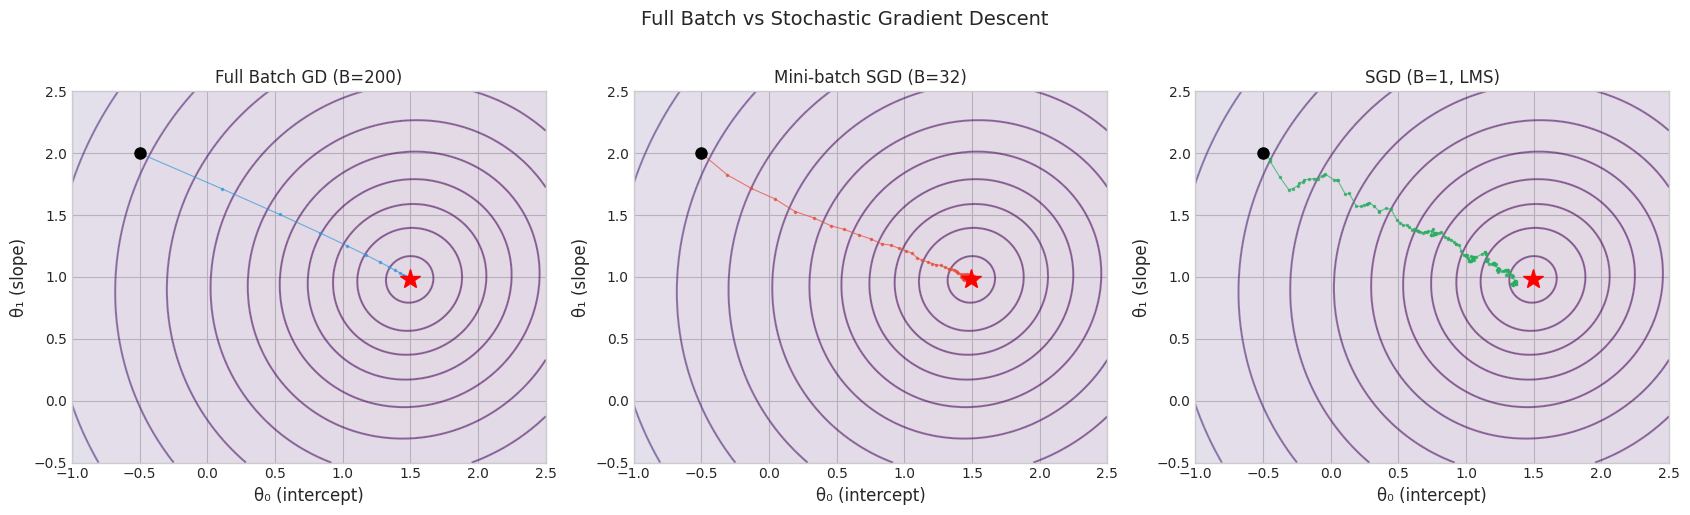

Full-batch GD follows a smooth path to the optimum.
SGD (B=1) takes a noisy, wandering path but still converges.
Mini-batch SGD (B=32) is a practical middle ground.


In [6]:
# Contour plot of the loss surface with trajectories
t1 = np.linspace(-1.0, 2.5, 200)
t2 = np.linspace(-0.5, 2.5, 200)
T1, T2 = np.meshgrid(t1, t2)
Z = np.zeros_like(T1)
for i in range(T1.shape[0]):
    for j in range(T1.shape[1]):
        Z[i, j] = linear_loss(np.array([T1[i, j], T2[i, j]]), X_simple, y_simple)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
levels = np.logspace(-1.5, 1.5, 20)

configs = [
    (path_full, 'Full Batch GD (B=200)', '#3498db'),
    (path_mini, 'Mini-batch SGD (B=32)', '#e74c3c'),
    (path_sgd1, 'SGD (B=1, LMS)', '#27ae60'),
]

for ax, (path, label, color) in zip(axes, configs):
    ax.contour(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.5)
    ax.contourf(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.15)
    ax.plot(path[:, 0], path[:, 1], '.-', color=color, markersize=3, linewidth=0.8, alpha=0.7)
    ax.plot(*theta0, 'ko', markersize=8)
    ax.plot(*theta_ols, 'r*', markersize=15, zorder=5)
    ax.set_xlabel('θ₀ (intercept)', fontsize=12)
    ax.set_ylabel('θ₁ (slope)', fontsize=12)
    ax.set_title(label, fontsize=12)

plt.suptitle('Full Batch vs Stochastic Gradient Descent', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Full-batch GD follows a smooth path to the optimum.")
print("SGD (B=1) takes a noisy, wandering path but still converges.")
print("Mini-batch SGD (B=32) is a practical middle ground.")

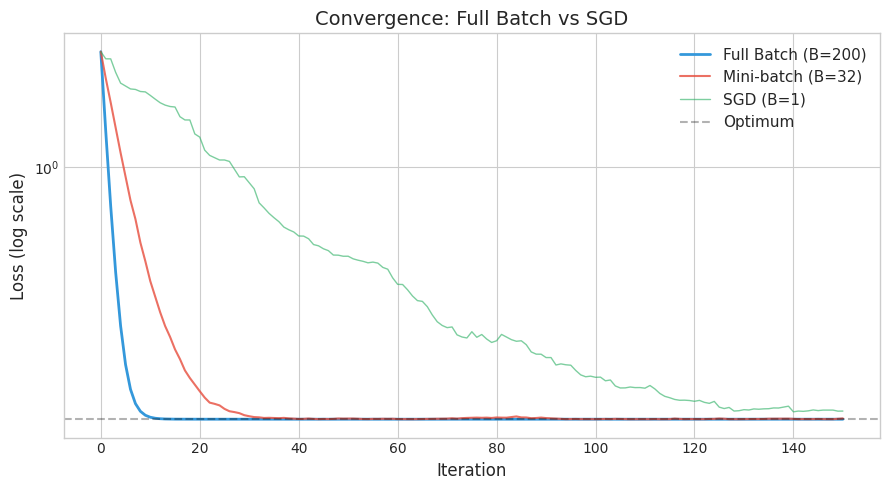

SGD doesn't decrease monotonically — the noise causes fluctuations.
But each step is much cheaper: B/N times the cost of a full gradient.


In [7]:
# Loss curves comparison
fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogy(losses_full, linewidth=2, color='#3498db', label='Full Batch (B=200)')
ax.semilogy(losses_mini, linewidth=1.5, color='#e74c3c', alpha=0.8, label='Mini-batch (B=32)')
ax.semilogy(losses_sgd1, linewidth=1, color='#27ae60', alpha=0.6, label='SGD (B=1)')
ax.axhline(linear_loss(theta_ols, X_simple, y_simple), color='k', linestyle='--', alpha=0.3, label='Optimum')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss (log scale)', fontsize=12)
ax.set_title('Convergence: Full Batch vs SGD', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("SGD doesn't decrease monotonically — the noise causes fluctuations.")
print("But each step is much cheaper: B/N times the cost of a full gradient.")

## 2. Effect of Minibatch Size

The minibatch size $B$ controls the **variance** of the gradient estimate:

$$\text{Var}[\hat{\mathbf{g}}] = \frac{\sigma^2}{B}$$

where $\sigma^2$ is the per-example gradient variance. Larger $B$ means lower variance (smoother path) but more computation per step.

**Key insight**: Even if the dataset has duplicate examples, SGD won't waste time on them — unlike full-batch GD which computes redundant gradients.

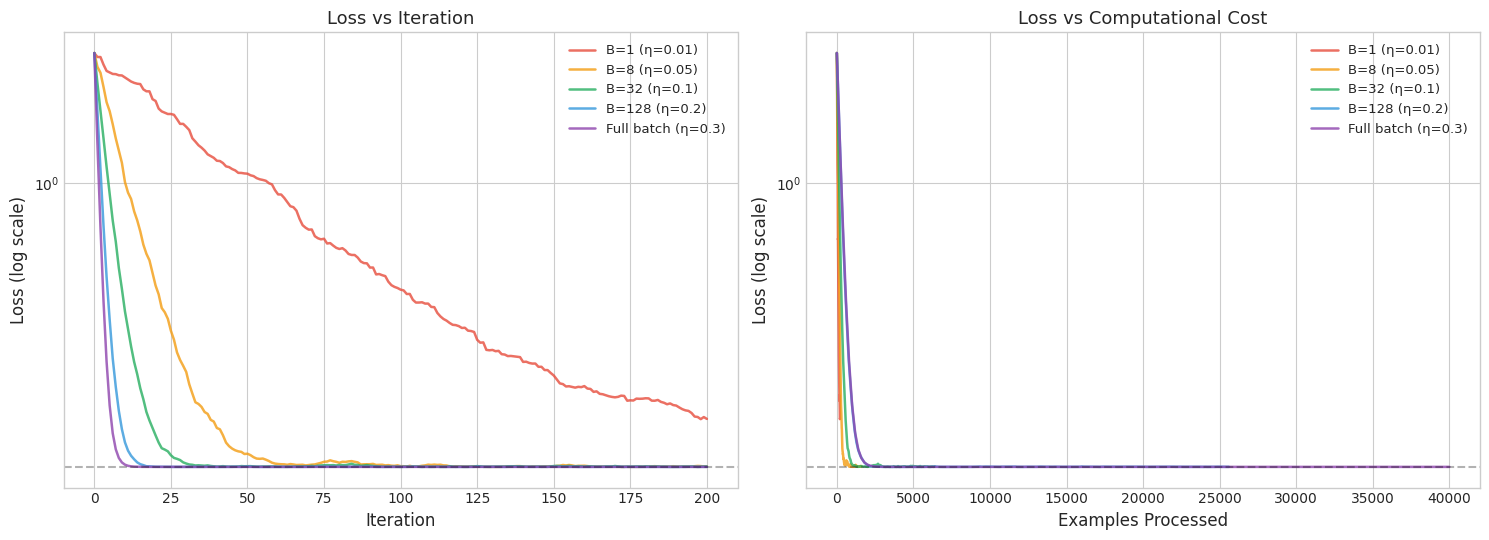

Left: Small batches converge in fewer iterations but with more noise.
Right: When accounting for per-step cost, small batches often win early on.


In [8]:
# Compare different batch sizes
batch_sizes = [1, 8, 32, 128, N]
lrs = [0.01, 0.05, 0.1, 0.2, 0.3]  # tuned per batch size
colors = ['#e74c3c', '#f39c12', '#27ae60', '#3498db', '#8e44ad']

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: loss vs iteration
ax = axes[0]
for bs, lr, col in zip(batch_sizes, lrs, colors):
    np.random.seed(0)
    _, losses = run_sgd(theta0, X_simple, y_simple, batch_size=bs, lr=lr, n_steps=200)
    label = f'B={bs}' if bs < N else 'Full batch'
    ax.semilogy(losses, linewidth=1.8, color=col, alpha=0.8, label=f'{label} (η={lr})')

ax.axhline(linear_loss(theta_ols, X_simple, y_simple), color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss (log scale)', fontsize=12)
ax.set_title('Loss vs Iteration', fontsize=13)
ax.legend(fontsize=9.5)

# Right: loss vs number of examples processed ("effective cost")
ax = axes[1]
for bs, lr, col in zip(batch_sizes, lrs, colors):
    np.random.seed(0)
    _, losses = run_sgd(theta0, X_simple, y_simple, batch_size=bs, lr=lr, n_steps=200)
    examples_seen = np.arange(len(losses)) * min(bs, N)
    label = f'B={bs}' if bs < N else 'Full batch'
    ax.semilogy(examples_seen, losses, linewidth=1.8, color=col, alpha=0.8, label=f'{label} (η={lr})')

ax.axhline(linear_loss(theta_ols, X_simple, y_simple), color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('Examples Processed', fontsize=12)
ax.set_ylabel('Loss (log scale)', fontsize=12)
ax.set_title('Loss vs Computational Cost', fontsize=13)
ax.legend(fontsize=9.5)

plt.tight_layout()
plt.show()

print("Left: Small batches converge in fewer iterations but with more noise.")
print("Right: When accounting for per-step cost, small batches often win early on.")

## 3. Learning Rate Schedules

A fixed learning rate won't converge to the exact optimum with SGD — the noise keeps pushing the iterates around. For convergence, the learning rate must satisfy the **Robbins-Monro conditions**:

$$\sum_{t=1}^{\infty} \eta_t = \infty \qquad \text{and} \qquad \sum_{t=1}^{\infty} \eta_t^2 < \infty$$

The first condition ensures we can reach any point in parameter space; the second ensures the noise vanishes.

### Common Schedules

| Schedule | Formula | Properties |
|----------|---------|------------|
| **Piecewise constant** | $\eta_t = \eta_i$ if $t_i \leq t < t_{i+1}$ | Simple; requires milestone tuning |
| **Exponential decay** | $\eta_t = \eta_0 e^{-\lambda t}$ | Often decays too fast |
| **Polynomial decay** | $\eta_t = \eta_0 (\beta t + 1)^{-\alpha}$ | Good default; $\alpha = 0.5$ common |
| **Cosine annealing** | $\eta_t = \frac{\eta_0}{2}\left(1 + \cos\frac{\pi t}{T}\right)$ | Smooth decay to zero |
| **Warmup + decay** | Linear increase then cosine/polynomial decrease | Standard for deep learning |

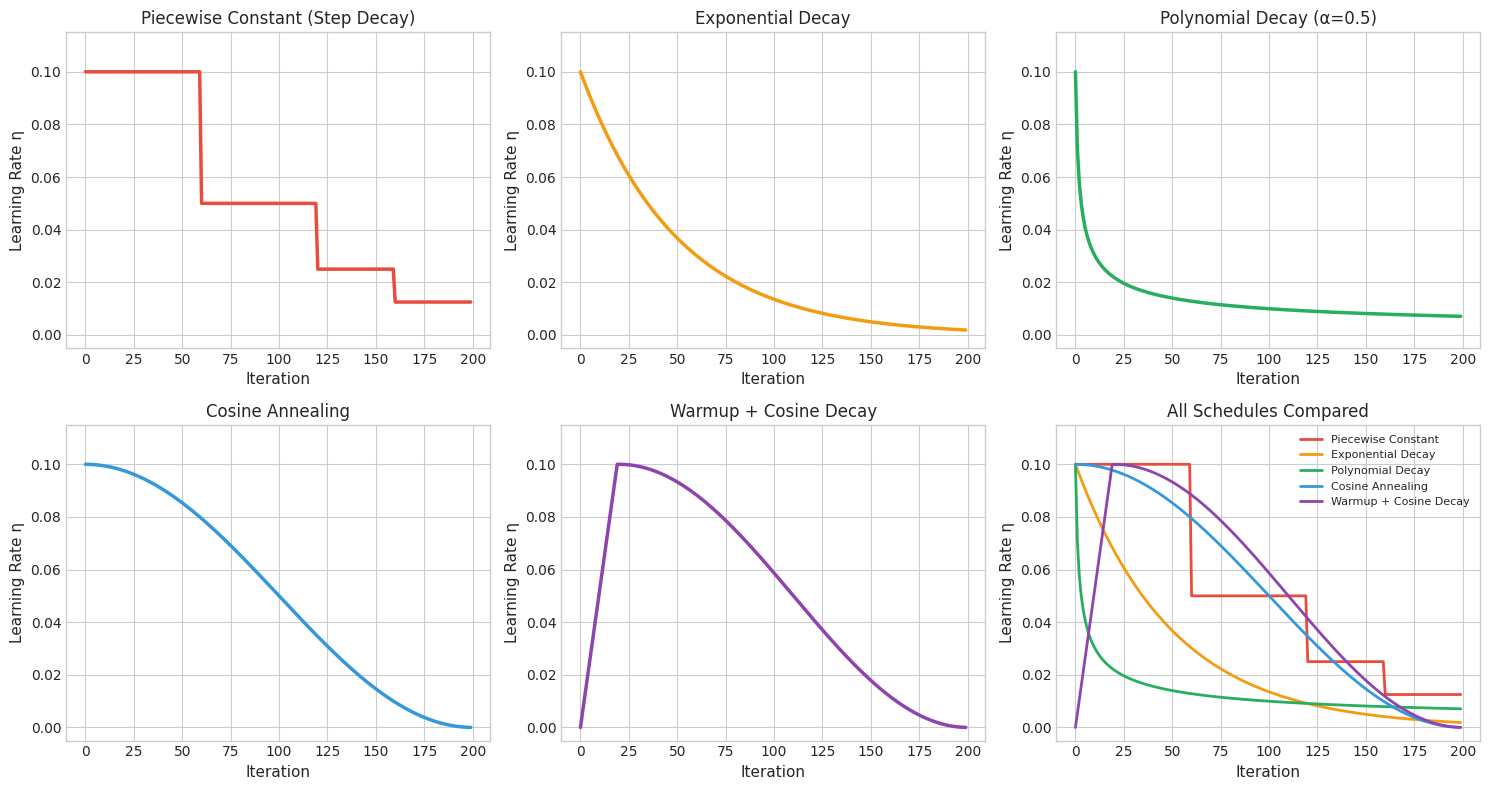

In [9]:
# Visualize learning rate schedules
T_total = 200
t = np.arange(T_total)
eta0 = 0.1

# Piecewise constant (step decay)
milestones = [60, 120, 160]
gamma = 0.5
eta_piecewise = np.full(T_total, eta0)
for ms in milestones:
    eta_piecewise[ms:] *= gamma

# Exponential decay
lam = 0.02
eta_exp = eta0 * np.exp(-lam * t)

# Polynomial decay (sqrt schedule, α=0.5)
eta_poly = eta0 / np.sqrt(t + 1)

# Cosine annealing
eta_cosine = 0.5 * eta0 * (1 + np.cos(np.pi * t / T_total))

# Warmup + cosine decay
warmup_steps = 20
eta_warmup_cosine = np.zeros(T_total)
eta_warmup_cosine[:warmup_steps] = eta0 * np.linspace(0, 1, warmup_steps)
t_after = np.arange(T_total - warmup_steps)
eta_warmup_cosine[warmup_steps:] = 0.5 * eta0 * (1 + np.cos(np.pi * t_after / (T_total - warmup_steps)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

schedules = [
    (eta_piecewise, 'Piecewise Constant (Step Decay)', '#e74c3c'),
    (eta_exp, 'Exponential Decay', '#f39c12'),
    (eta_poly, 'Polynomial Decay (α=0.5)', '#27ae60'),
    (eta_cosine, 'Cosine Annealing', '#3498db'),
    (eta_warmup_cosine, 'Warmup + Cosine Decay', '#8e44ad'),
]

for ax, (eta_sched, name, color) in zip(axes.flat, schedules):
    ax.plot(t, eta_sched, linewidth=2.5, color=color)
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Learning Rate η', fontsize=11)
    ax.set_title(name, fontsize=12)
    ax.set_ylim(-0.005, eta0 * 1.15)

# Overlay all in the last subplot
ax = axes[1, 2]
for eta_sched, name, color in schedules:
    ax.plot(t, eta_sched, linewidth=2, color=color, label=name.split('(')[0].strip())
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Learning Rate η', fontsize=11)
ax.set_title('All Schedules Compared', fontsize=12)
ax.legend(fontsize=8)
ax.set_ylim(-0.005, eta0 * 1.15)

plt.tight_layout()
plt.show()

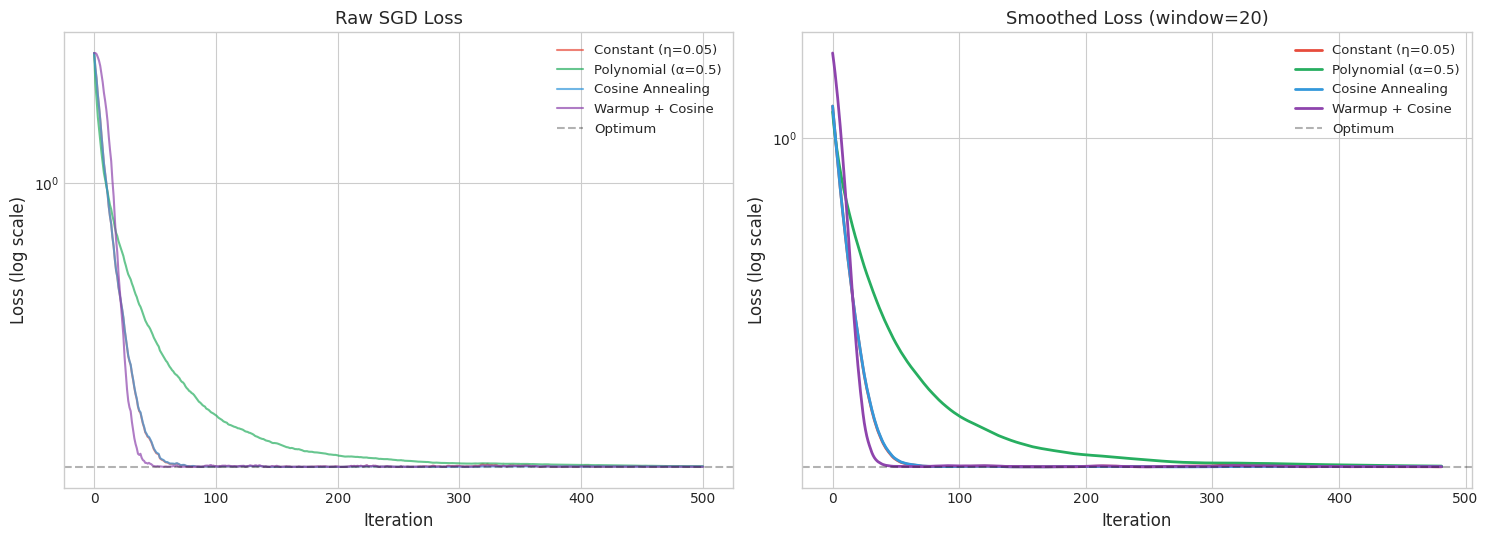

A constant learning rate oscillates around the optimum without converging.
Decaying schedules reduce the noise and converge closer to the true minimum.


In [10]:
# Compare learning rate schedules on SGD
def run_sgd_scheduled(theta0, X, y, batch_size, schedule_fn, n_steps):
    """SGD with a learning rate schedule."""
    theta = theta0.copy()
    path = [theta.copy()]
    losses = [linear_loss(theta, X, y)]
    for t in range(n_steps):
        lr = schedule_fn(t)
        g = linear_grad_minibatch(theta, X, y, batch_size)
        theta = theta - lr * g
        path.append(theta.copy())
        losses.append(linear_loss(theta, X, y))
    return np.array(path), np.array(losses)

n_steps_sched = 500
bs = 16

schedule_configs = [
    ('Constant (η=0.05)', lambda t: 0.05, '#e74c3c'),
    ('Polynomial (α=0.5)', lambda t: 0.1 / np.sqrt(t + 1), '#27ae60'),
    ('Cosine Annealing', lambda t: 0.05 * (1 + np.cos(np.pi * t / n_steps_sched)) / 2, '#3498db'),
    ('Warmup + Cosine', lambda t: (0.1 * (t / 20) if t < 20 else 0.1 * (1 + np.cos(np.pi * (t - 20) / (n_steps_sched - 20))) / 2), '#8e44ad'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

opt_loss = linear_loss(theta_ols, X_simple, y_simple)

for name, sched_fn, color in schedule_configs:
    np.random.seed(42)
    _, losses = run_sgd_scheduled(theta0, X_simple, y_simple, bs, sched_fn, n_steps_sched)
    axes[0].semilogy(losses, linewidth=1.5, color=color, alpha=0.7, label=name)
    # Smoothed version (running average over window of 20)
    window = 20
    smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    axes[1].semilogy(smoothed, linewidth=2, color=color, label=name)

for ax in axes:
    ax.axhline(opt_loss, color='k', linestyle='--', alpha=0.3, label='Optimum')
    ax.set_xlabel('Iteration', fontsize=12)
    ax.set_ylabel('Loss (log scale)', fontsize=12)
    ax.legend(fontsize=9.5)

axes[0].set_title('Raw SGD Loss', fontsize=13)
axes[1].set_title('Smoothed Loss (window=20)', fontsize=13)

plt.tight_layout()
plt.show()

print("A constant learning rate oscillates around the optimum without converging.")
print("Decaying schedules reduce the noise and converge closer to the true minimum.")

## 4. Iterate Averaging (Polyak-Ruppert)

SGD iterates are noisy. A simple but powerful technique is **iterate averaging**: keep a running average of all past parameter vectors:

$$\bar{\boldsymbol{\theta}}_t = \frac{1}{t} \sum_{i=1}^{t} \boldsymbol{\theta}_i = \frac{1}{t} \boldsymbol{\theta}_t + \frac{t-1}{t} \bar{\boldsymbol{\theta}}_{t-1}$$

This is known as **Polyak-Ruppert averaging**. It achieves the optimal convergence rate for SGD — matching methods that use second-order information like Hessians.

For linear regression, iterate averaging is equivalent to $\ell_2$ regularization (ridge regression).

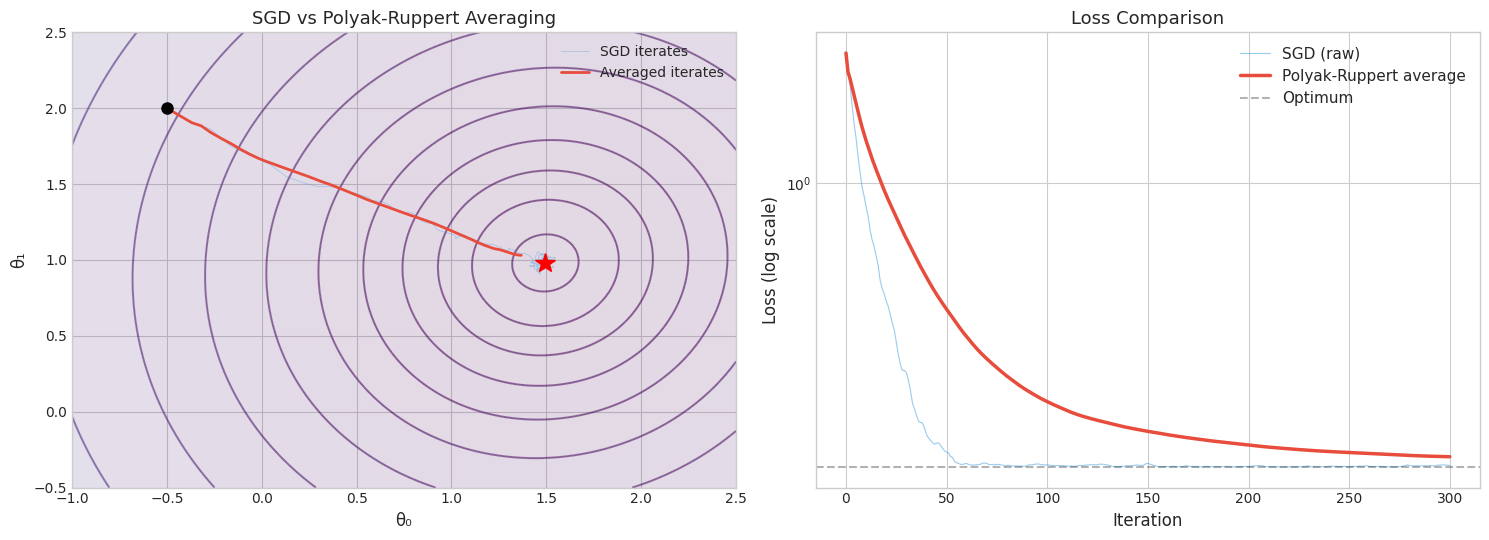

Final loss (SGD raw):   0.121349
Final loss (averaged):  0.129546
Optimal loss:           0.120066

Averaging smooths out the noise and converges closer to the optimum.


In [11]:
def run_sgd_with_averaging(theta0, X, y, batch_size, lr, n_steps):
    """SGD with Polyak-Ruppert iterate averaging."""
    theta = theta0.copy()
    theta_avg = theta0.copy()
    path = [theta.copy()]
    path_avg = [theta_avg.copy()]
    losses = [linear_loss(theta, X, y)]
    losses_avg = [linear_loss(theta_avg, X, y)]
    for t in range(1, n_steps + 1):
        g = linear_grad_minibatch(theta, X, y, batch_size)
        theta = theta - lr * g
        # Running average: theta_avg = (1/t) * theta + (1 - 1/t) * theta_avg
        theta_avg = theta / t + theta_avg * (t - 1) / t
        path.append(theta.copy())
        path_avg.append(theta_avg.copy())
        losses.append(linear_loss(theta, X, y))
        losses_avg.append(linear_loss(theta_avg, X, y))
    return np.array(path), np.array(path_avg), np.array(losses), np.array(losses_avg)

np.random.seed(42)
path_raw, path_avg, losses_raw, losses_avg = run_sgd_with_averaging(
    theta0, X_simple, y_simple, batch_size=8, lr=0.05, n_steps=300)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: trajectories
ax = axes[0]
ax.contour(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.5)
ax.contourf(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.15)
ax.plot(path_raw[:, 0], path_raw[:, 1], '-', color='#3498db', linewidth=0.5, alpha=0.4, label='SGD iterates')
ax.plot(path_avg[:, 0], path_avg[:, 1], '-', color='#e74c3c', linewidth=2, label='Averaged iterates')
ax.plot(*theta0, 'ko', markersize=8)
ax.plot(*theta_ols, 'r*', markersize=15, zorder=5)
ax.set_xlabel('θ₀', fontsize=12)
ax.set_ylabel('θ₁', fontsize=12)
ax.set_title('SGD vs Polyak-Ruppert Averaging', fontsize=13)
ax.legend(fontsize=10)

# Right: loss curves
ax = axes[1]
ax.semilogy(losses_raw, color='#3498db', linewidth=0.8, alpha=0.5, label='SGD (raw)')
ax.semilogy(losses_avg, color='#e74c3c', linewidth=2.5, label='Polyak-Ruppert average')
ax.axhline(opt_loss, color='k', linestyle='--', alpha=0.3, label='Optimum')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss (log scale)', fontsize=12)
ax.set_title('Loss Comparison', fontsize=13)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"Final loss (SGD raw):   {losses_raw[-1]:.6f}")
print(f"Final loss (averaged):  {losses_avg[-1]:.6f}")
print(f"Optimal loss:           {opt_loss:.6f}")
print("\nAveraging smooths out the noise and converges closer to the optimum.")

## 5. Preconditioned SGD: Adaptive Learning Rates

Vanilla SGD uses the same learning rate for all parameters. **Preconditioned SGD** scales each parameter differently:

$$\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta_t \mathbf{M}_t^{-1} \mathbf{g}_t$$

where $\mathbf{M}_t$ is a **preconditioning matrix**. In practice, we use diagonal $\mathbf{M}_t$ to keep things efficient.

### 5.1 AdaGrad

**AdaGrad** accumulates the sum of squared gradients to scale each dimension:

$$s_{t,d} = \sum_{i=1}^{t} g_{i,d}^2$$

$$\theta_{t+1,d} = \theta_{t,d} - \frac{\eta_t}{\sqrt{s_{t,d} + \epsilon}} \, g_{t,d}$$

Parameters with large accumulated gradients get smaller effective learning rates. This is useful for **sparse features** (e.g., rare words or infrequent gene markers).

**Drawback**: The denominator only grows, so the effective learning rate monotonically decreases — eventually stalling.

### 5.2 RMSProp

**RMSProp** fixes AdaGrad's decay problem by using an **exponential moving average** of squared gradients:

$$s_{t+1,d} = \beta_2 \, s_{t,d} + (1 - \beta_2) \, g_{t,d}^2$$

$$\theta_{t+1,d} = \theta_{t,d} - \frac{\eta_t}{\sqrt{s_{t,d} + \epsilon}} \, g_{t,d}$$

Typical value: $\beta_2 = 0.9$. This forgets old gradients, keeping the effective learning rate from vanishing.

### 5.3 Adam

**Adam** (Adaptive Moment Estimation) combines **momentum** (EWMA of gradients) with **RMSProp** (EWMA of squared gradients):

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) \mathbf{g}_t \qquad \text{(first moment)}$$

$$s_t = \beta_2 s_{t-1} + (1 - \beta_2) \mathbf{g}_t^2 \qquad \text{(second moment)}$$

With **bias correction** to account for zero initialization:

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \qquad \hat{s}_t = \frac{s_t}{1 - \beta_2^t}$$

$$\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta_t \frac{\hat{m}_t}{\sqrt{\hat{s}_t} + \epsilon}$$

Default hyperparameters: $\beta_1 = 0.9$, $\beta_2 = 0.999$, $\epsilon = 10^{-6}$, $\eta = 0.001$.

In [12]:
class SGDOptimizer:
    """Vanilla SGD."""
    def __init__(self, lr=0.01):
        self.lr = lr
    
    def step(self, theta, g, t):
        return theta - self.lr * g

class AdaGrad:
    """AdaGrad optimizer."""
    def __init__(self, lr=0.1, eps=1e-8):
        self.lr = lr
        self.eps = eps
        self.s = None
    
    def step(self, theta, g, t):
        if self.s is None:
            self.s = np.zeros_like(theta)
        self.s += g**2
        return theta - self.lr * g / (np.sqrt(self.s) + self.eps)

class RMSProp:
    """RMSProp optimizer."""
    def __init__(self, lr=0.01, beta2=0.9, eps=1e-8):
        self.lr = lr
        self.beta2 = beta2
        self.eps = eps
        self.s = None
    
    def step(self, theta, g, t):
        if self.s is None:
            self.s = np.zeros_like(theta)
        self.s = self.beta2 * self.s + (1 - self.beta2) * g**2
        return theta - self.lr * g / (np.sqrt(self.s) + self.eps)

class Adam:
    """Adam optimizer with bias correction."""
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-6):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.m = None
        self.s = None
    
    def step(self, theta, g, t):
        if self.m is None:
            self.m = np.zeros_like(theta)
            self.s = np.zeros_like(theta)
        self.m = self.beta1 * self.m + (1 - self.beta1) * g
        self.s = self.beta2 * self.s + (1 - self.beta2) * g**2
        # Bias correction
        m_hat = self.m / (1 - self.beta1**t)
        s_hat = self.s / (1 - self.beta2**t)
        return theta - self.lr * m_hat / (np.sqrt(s_hat) + self.eps)

def run_optimizer(opt, theta0, X, y, batch_size, n_steps):
    """Run an optimizer on the linear regression problem."""
    theta = theta0.copy()
    path = [theta.copy()]
    losses = [linear_loss(theta, X, y)]
    for t in range(1, n_steps + 1):
        g = linear_grad_minibatch(theta, X, y, batch_size)
        theta = opt.step(theta, g, t)
        path.append(theta.copy())
        losses.append(linear_loss(theta, X, y))
    return np.array(path), np.array(losses)

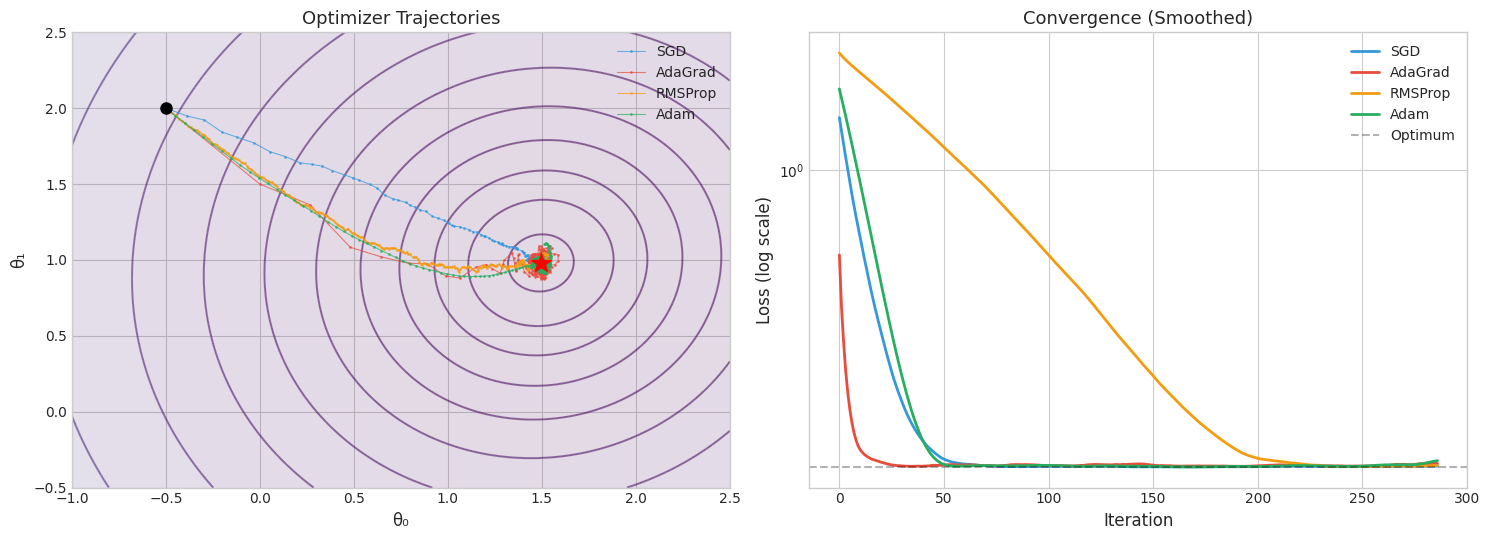

In [13]:
# Compare all optimizers on the 2D linear regression problem
n_steps_opt = 300
bs_opt = 16

optimizers = [
    ('SGD', SGDOptimizer(lr=0.05), '#3498db'),
    ('AdaGrad', AdaGrad(lr=0.5), '#e74c3c'),
    ('RMSProp', RMSProp(lr=0.01, beta2=0.9), '#f39c12'),
    ('Adam', Adam(lr=0.05, beta1=0.9, beta2=0.999), '#27ae60'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: trajectories
ax = axes[0]
ax.contour(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.5)
ax.contourf(T1, T2, Z, levels=levels, cmap='viridis', alpha=0.15)

for name, opt, color in optimizers:
    np.random.seed(42)
    path, losses = run_optimizer(opt, theta0, X_simple, y_simple, bs_opt, n_steps_opt)
    ax.plot(path[:, 0], path[:, 1], '.-', color=color, markersize=2, linewidth=0.8, alpha=0.7, label=name)

ax.plot(*theta0, 'ko', markersize=8)
ax.plot(*theta_ols, 'r*', markersize=15, zorder=5)
ax.set_xlabel('θ₀', fontsize=12)
ax.set_ylabel('θ₁', fontsize=12)
ax.set_title('Optimizer Trajectories', fontsize=13)
ax.legend(fontsize=10)

# Right: smoothed loss curves
ax = axes[1]
window = 15
for name, opt_class, color in [
    ('SGD', SGDOptimizer(lr=0.05), '#3498db'),
    ('AdaGrad', AdaGrad(lr=0.5), '#e74c3c'),
    ('RMSProp', RMSProp(lr=0.01, beta2=0.9), '#f39c12'),
    ('Adam', Adam(lr=0.05, beta1=0.9, beta2=0.999), '#27ae60'),
]:
    np.random.seed(42)
    _, losses = run_optimizer(opt_class, theta0, X_simple, y_simple, bs_opt, n_steps_opt)
    smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    ax.semilogy(smoothed, linewidth=2, color=color, label=name)

ax.axhline(opt_loss, color='k', linestyle='--', alpha=0.3, label='Optimum')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss (log scale)', fontsize=12)
ax.set_title('Convergence (Smoothed)', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### How Adam's Bias Correction Works *

Since $m_0 = s_0 = 0$, the first few estimates of $m_t$ and $s_t$ are biased toward zero. Taking the expected value:

$$\mathbb{E}[m_t] = (1 - \beta_1^t) \, \mathbb{E}[\mathbf{g}]$$

So dividing by $(1 - \beta_1^t)$ gives an **unbiased estimate**. The correction is significant early on (when $\beta_1^t$ is large) and vanishes as $t \to \infty$.

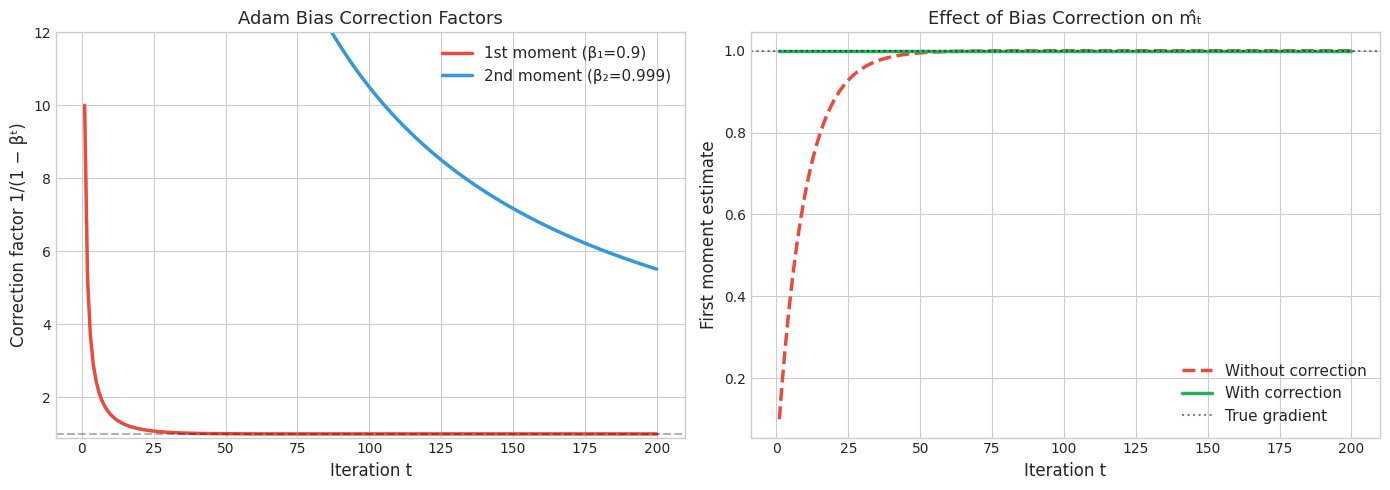

At t=1: correction multiplies m by 10.0× and s by 1000×
At t=10: m by 1.54× and s by 100.5×
At t=100: m by 1.0000× and s by 10.50×


In [14]:
# Visualize bias correction factors
beta1, beta2 = 0.9, 0.999
t_range = np.arange(1, 201)

correction_m = 1 / (1 - beta1**t_range)
correction_s = 1 / (1 - beta2**t_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(t_range, correction_m, linewidth=2.5, color='#e74c3c', label=f'1st moment (β₁={beta1})')
ax.plot(t_range, correction_s, linewidth=2.5, color='#3498db', label=f'2nd moment (β₂={beta2})')
ax.axhline(1.0, color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('Iteration t', fontsize=12)
ax.set_ylabel('Correction factor 1/(1 − βᵗ)', fontsize=12)
ax.set_title('Adam Bias Correction Factors', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0.9, 12)

# Show effective learning rate with and without correction
ax = axes[1]
# Simulate constant gradient to show effect
g_const = 1.0
m_no_corr = np.zeros(len(t_range))
m_corrected = np.zeros(len(t_range))
m_val = 0.0
for i, t in enumerate(t_range):
    m_val = beta1 * m_val + (1 - beta1) * g_const
    m_no_corr[i] = m_val
    m_corrected[i] = m_val / (1 - beta1**t)

ax.plot(t_range, m_no_corr, linewidth=2.5, color='#e74c3c', linestyle='--', label='Without correction')
ax.plot(t_range, m_corrected, linewidth=2.5, color='#27ae60', label='With correction')
ax.axhline(g_const, color='k', linestyle=':', alpha=0.5, label='True gradient')
ax.set_xlabel('Iteration t', fontsize=12)
ax.set_ylabel('First moment estimate', fontsize=12)
ax.set_title('Effect of Bias Correction on m̂ₜ', fontsize=13)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"At t=1: correction multiplies m by {1/(1-beta1**1):.1f}× and s by {1/(1-beta2**1):.0f}×")
print(f"At t=10: m by {1/(1-beta1**10):.2f}× and s by {1/(1-beta2**10):.1f}×")
print(f"At t=100: m by {1/(1-beta1**100):.4f}× and s by {1/(1-beta2**100):.2f}×")

### AdaGrad vs RMSProp: The Accumulation Problem

A key difference between AdaGrad and RMSProp is how they accumulate squared gradients:

| Method | Accumulation | Effect |
|--------|-------------|--------|
| **AdaGrad** | $s_t = \sum_{i=1}^t g_i^2$ (sum) | Effective LR → 0 monotonically |
| **RMSProp** | $s_t = \beta s_{t-1} + (1-\beta) g_t^2$ (EWMA) | Effective LR adapts to recent gradients |

AdaGrad's monotonic decay is fine for **convex** problems (where we want convergence), but can stall prematurely on **non-convex** problems (like deep learning) where the loss landscape changes.

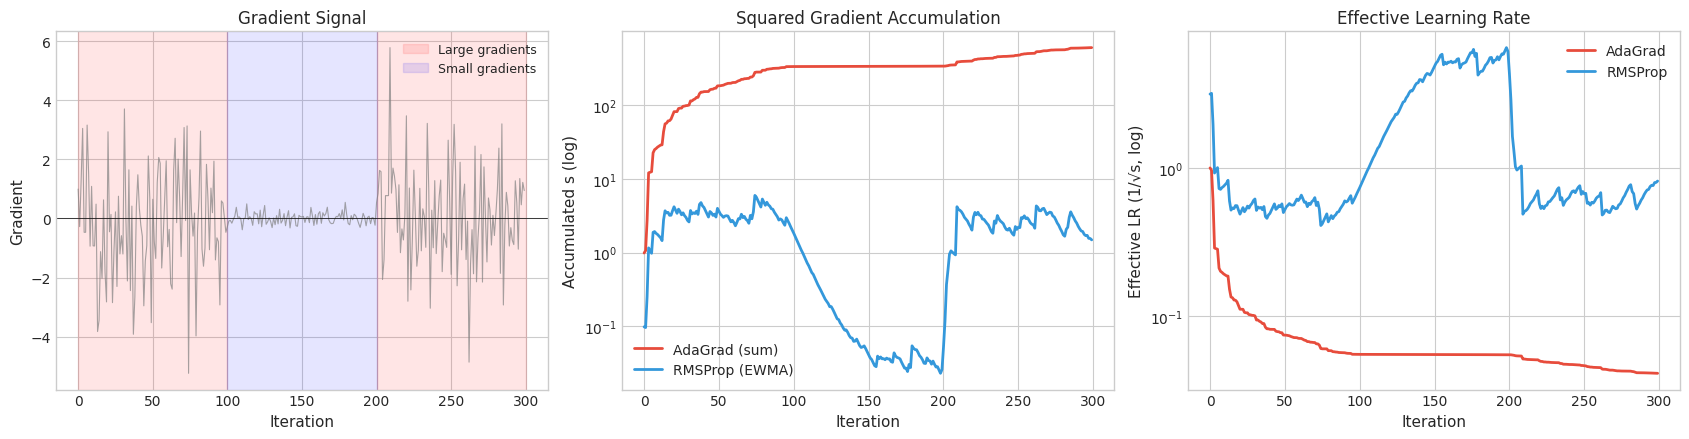

AdaGrad's effective LR only decreases — it can't recover in the flat region.
RMSProp adapts: the LR increases when gradients become small, then decreases again.


In [15]:
# Visualize effective learning rates over time for AdaGrad vs RMSProp
# Simulate with a gradient that changes magnitude
np.random.seed(42)
n_sim = 300
# Gradients: large early, then small, then large again
g_sim = np.concatenate([
    np.random.randn(100) * 2.0,   # large gradients
    np.random.randn(100) * 0.2,   # small gradients (flat region)
    np.random.randn(100) * 1.5,   # large again (new feature)
])

# AdaGrad accumulation
s_adagrad = np.cumsum(g_sim**2)
eff_lr_adagrad = 1.0 / (np.sqrt(s_adagrad) + 1e-8)

# RMSProp accumulation
beta_rms = 0.9
s_rmsprop = np.zeros(n_sim)
s_val = 0.0
for i in range(n_sim):
    s_val = beta_rms * s_val + (1 - beta_rms) * g_sim[i]**2
    s_rmsprop[i] = s_val
eff_lr_rmsprop = 1.0 / (np.sqrt(s_rmsprop) + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

ax = axes[0]
ax.plot(g_sim, linewidth=0.8, color='gray', alpha=0.7)
ax.axhline(0, color='k', linewidth=0.5)
ax.axvspan(0, 100, alpha=0.1, color='red', label='Large gradients')
ax.axvspan(100, 200, alpha=0.1, color='blue', label='Small gradients')
ax.axvspan(200, 300, alpha=0.1, color='red')
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Gradient', fontsize=11)
ax.set_title('Gradient Signal', fontsize=12)
ax.legend(fontsize=9)

ax = axes[1]
ax.semilogy(s_adagrad, linewidth=2, color='#e74c3c', label='AdaGrad (sum)')
ax.semilogy(s_rmsprop, linewidth=2, color='#3498db', label='RMSProp (EWMA)')
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Accumulated s (log)', fontsize=11)
ax.set_title('Squared Gradient Accumulation', fontsize=12)
ax.legend(fontsize=10)

ax = axes[2]
ax.semilogy(eff_lr_adagrad, linewidth=2, color='#e74c3c', label='AdaGrad')
ax.semilogy(eff_lr_rmsprop, linewidth=2, color='#3498db', label='RMSProp')
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Effective LR (1/√s, log)', fontsize=11)
ax.set_title('Effective Learning Rate', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print("AdaGrad's effective LR only decreases — it can't recover in the flat region.")
print("RMSProp adapts: the LR increases when gradients become small, then decreases again.")

## 6. Application: Drug Sensitivity Prediction

Now let's apply these methods to our biotech problem. We have $N = 2000$ cancer cell lines, each characterized by $D = 50$ gene expression features. The target is the drug sensitivity score (log IC50).

We fit a **linear regression** model using different SGD variants. With $N = 2000$, full-batch GD processes all examples every step, while mini-batch SGD with $B = 64$ is ~30× cheaper per step.

In [16]:
# Generate synthetic drug sensitivity dataset
np.random.seed(42)
N_drug = 2000
D = 50

# Gene expression features (standardized)
# Some features are correlated (genes in same pathway)
cov = np.eye(D)
for i in range(0, D - 1, 2):  # pairs of correlated genes
    cov[i, i+1] = 0.6
    cov[i+1, i] = 0.6
L_cov = np.linalg.cholesky(cov)
X_drug = np.random.randn(N_drug, D) @ L_cov.T

# True coefficients: sparse (only ~10 genes matter)
theta_drug_true = np.zeros(D)
important_genes = [0, 3, 7, 12, 18, 25, 31, 38, 42, 47]
theta_drug_true[important_genes] = np.random.randn(len(important_genes)) * 2

# Drug sensitivity = linear combination + noise
y_drug = X_drug @ theta_drug_true + np.random.randn(N_drug) * 1.5

# OLS solution for reference
theta_drug_ols = np.linalg.lstsq(X_drug, y_drug, rcond=None)[0]
loss_drug_opt = 0.5 * np.mean((X_drug @ theta_drug_ols - y_drug)**2)

print(f"Dataset: {N_drug} cell lines × {D} gene features")
print(f"Active genes: {len(important_genes)} / {D}")
print(f"OLS optimal loss: {loss_drug_opt:.4f}")
print(f"Condition number of X^TX/N: {np.linalg.cond(X_drug.T @ X_drug / N_drug):.1f}")

Dataset: 2000 cell lines × 50 gene features
Active genes: 10 / 50
OLS optimal loss: 1.0932
Condition number of X^TX/N: 6.3


In [17]:
def linear_loss_general(theta, X, y):
    return 0.5 * np.mean((X @ theta - y)**2)

def linear_grad_minibatch_general(theta, X, y, batch_size):
    idx = np.random.choice(len(y), size=batch_size, replace=False)
    residuals = X[idx] @ theta - y[idx]
    return X[idx].T @ residuals / batch_size

def run_optimizer_general(opt, theta0, X, y, batch_size, n_steps):
    theta = theta0.copy()
    losses = [linear_loss_general(theta, X, y)]
    for t in range(1, n_steps + 1):
        g = linear_grad_minibatch_general(theta, X, y, batch_size)
        theta = opt.step(theta, g, t)
        losses.append(linear_loss_general(theta, X, y))
    return theta, np.array(losses)

# Run each optimizer
theta0_drug = np.zeros(D)
n_steps_drug = 1000
bs_drug = 64

results = {}
for name, opt in [
    ('SGD (η=0.01)', SGDOptimizer(lr=0.01)),
    ('AdaGrad (η=0.1)', AdaGrad(lr=0.1)),
    ('RMSProp (η=0.001)', RMSProp(lr=0.001, beta2=0.9)),
    ('Adam (η=0.005)', Adam(lr=0.005, beta1=0.9, beta2=0.999)),
]:
    np.random.seed(42)
    theta_final, losses = run_optimizer_general(opt, theta0_drug, X_drug, y_drug, bs_drug, n_steps_drug)
    results[name] = (theta_final, losses)
    print(f"{name:25s}: final loss = {losses[-1]:.4f}")

print(f"{'OLS optimal':25s}: final loss = {loss_drug_opt:.4f}")

SGD (η=0.01)             : final loss = 1.0997
AdaGrad (η=0.1)          : final loss = 1.1310
RMSProp (η=0.001)        : final loss = 5.8567
Adam (η=0.005)           : final loss = 1.3689
OLS optimal              : final loss = 1.0932


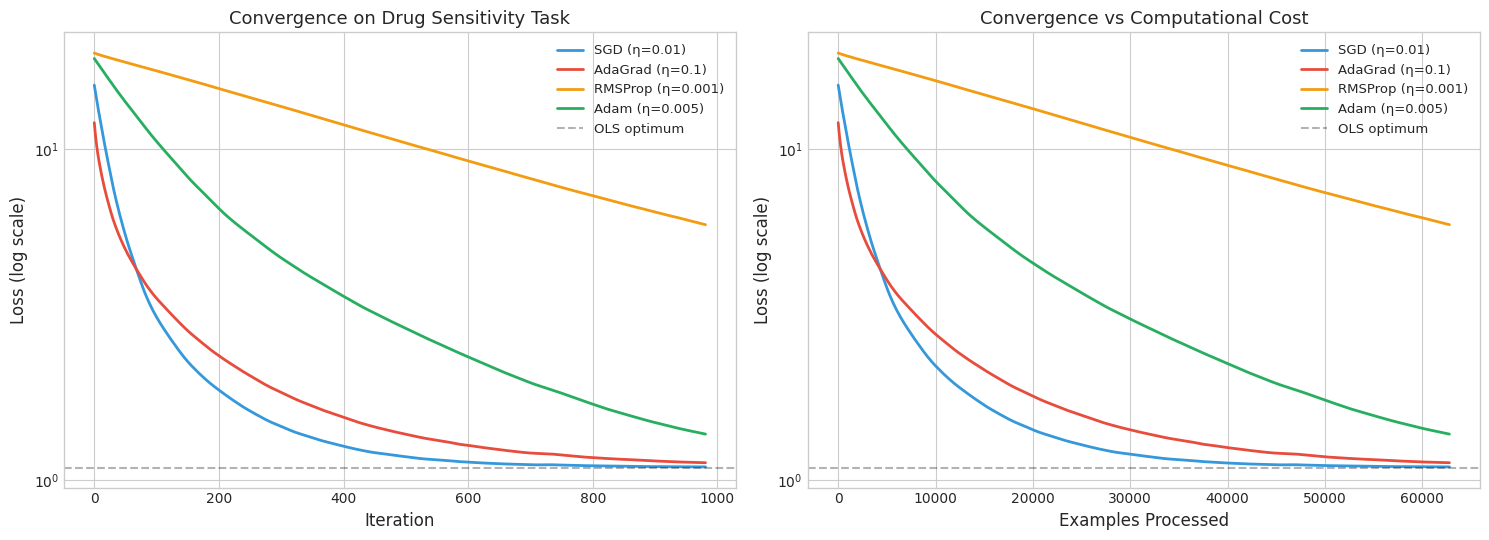

In [18]:
# Convergence comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
colors = {'SGD (η=0.01)': '#3498db', 'AdaGrad (η=0.1)': '#e74c3c',
          'RMSProp (η=0.001)': '#f39c12', 'Adam (η=0.005)': '#27ae60'}

# Left: loss vs iteration
ax = axes[0]
window = 20
for name, (_, losses) in results.items():
    smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    ax.semilogy(smoothed, linewidth=2, color=colors[name], label=name)
ax.axhline(loss_drug_opt, color='k', linestyle='--', alpha=0.3, label='OLS optimum')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss (log scale)', fontsize=12)
ax.set_title('Convergence on Drug Sensitivity Task', fontsize=13)
ax.legend(fontsize=9.5)

# Right: loss vs examples processed
ax = axes[1]
for name, (_, losses) in results.items():
    examples = np.arange(len(losses)) * bs_drug
    smoothed = np.convolve(losses, np.ones(window)/window, mode='valid')
    examples_smooth = np.arange(len(smoothed)) * bs_drug
    ax.semilogy(examples_smooth, smoothed, linewidth=2, color=colors[name], label=name)
ax.axhline(loss_drug_opt, color='k', linestyle='--', alpha=0.3, label='OLS optimum')
ax.set_xlabel('Examples Processed', fontsize=12)
ax.set_ylabel('Loss (log scale)', fontsize=12)
ax.set_title('Convergence vs Computational Cost', fontsize=13)
ax.legend(fontsize=9.5)

plt.tight_layout()
plt.show()

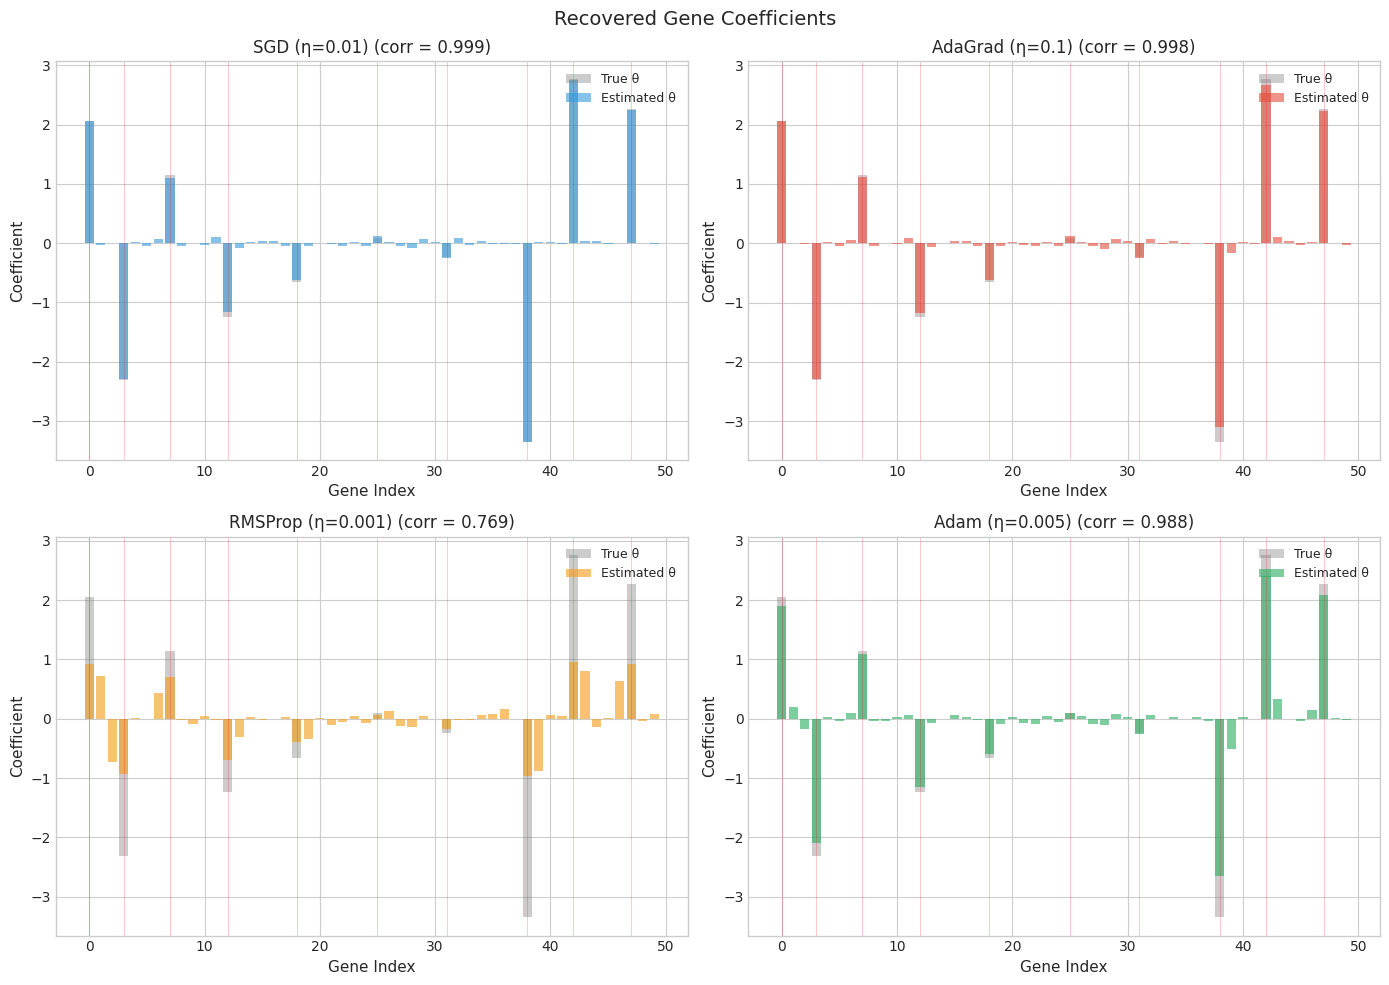

Red vertical lines mark the truly important genes.
Adaptive methods (Adam, AdaGrad) tend to find the sparse structure faster.


In [19]:
# Compare recovered coefficients
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, (theta_final, _)) in zip(axes.flat, results.items()):
    ax.bar(range(D), theta_drug_true, alpha=0.4, color='gray', label='True θ')
    ax.bar(range(D), theta_final, alpha=0.6, color=colors[name], label='Estimated θ')
    # Highlight important genes
    for ig in important_genes:
        ax.axvline(ig, color='red', linewidth=0.5, alpha=0.3)
    
    corr = np.corrcoef(theta_drug_true, theta_final)[0, 1]
    ax.set_xlabel('Gene Index', fontsize=11)
    ax.set_ylabel('Coefficient', fontsize=11)
    ax.set_title(f'{name} (corr = {corr:.3f})', fontsize=12)
    ax.legend(fontsize=9, loc='upper right')

plt.suptitle('Recovered Gene Coefficients', fontsize=14)
plt.tight_layout()
plt.show()

print("Red vertical lines mark the truly important genes.")
print("Adaptive methods (Adam, AdaGrad) tend to find the sparse structure faster.")

## 7. Non-Convex Landscape: SGD as Implicit Regularization

On non-convex problems, SGD's noise can actually **help** by allowing the optimizer to escape sharp local minima and find flatter minima that generalize better. This connects to the idea that SGD acts as an **implicit regularizer**.

Let's visualize this on a 1D function with multiple local minima.

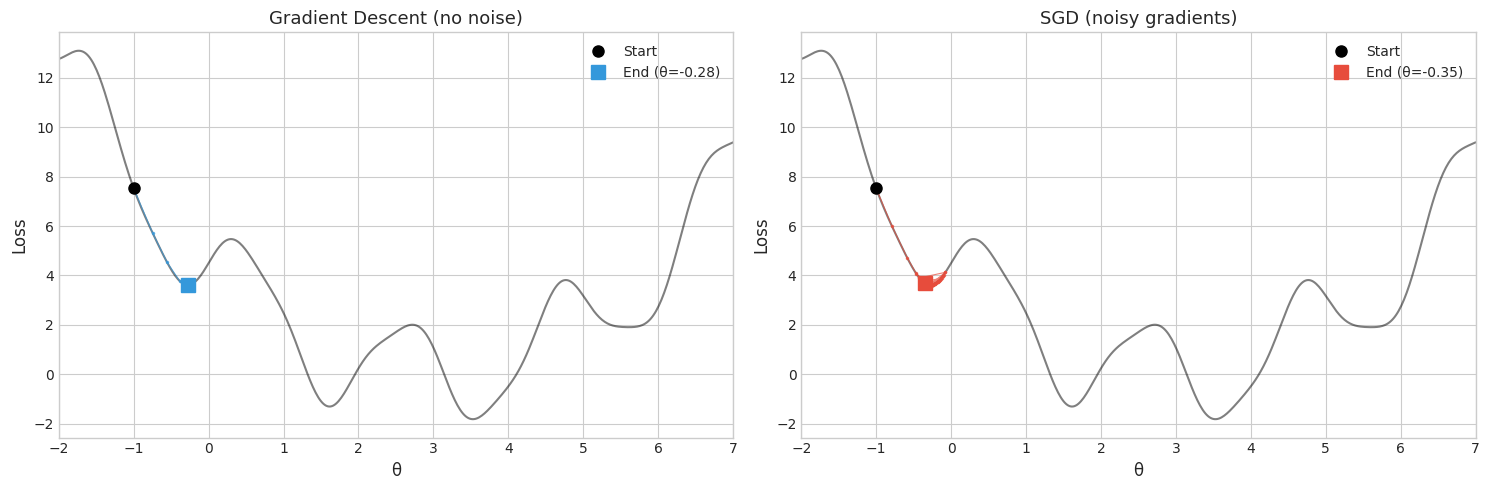

GD converges to the nearest local minimum at θ ≈ -0.28
SGD's noise helps it escape and find a better minimum at θ ≈ -0.35
GD final loss: 3.6123
SGD final loss: 3.6828


In [20]:
# 1D non-convex landscape
def nonconvex_loss(theta):
    """A 1D function with sharp and flat minima."""
    return (0.5 * (theta - 3)**2 +  # broad basin centered at 3
            2.0 * np.sin(3 * theta) +  # oscillations creating local minima
            0.3 * np.sin(7 * theta))  # higher-frequency ripples

def nonconvex_grad(theta, noise_std=0.0):
    """Gradient with optional noise (simulating stochasticity)."""
    eps = 1e-5
    g = (nonconvex_loss(theta + eps) - nonconvex_loss(theta - eps)) / (2 * eps)
    return g + noise_std * np.random.randn()

# Run GD (no noise) and SGD (with noise) from the same starting point
theta_start = -1.0
n_steps_nc = 300
lr_nc = 0.03

# GD (deterministic)
np.random.seed(42)
theta_gd = theta_start
path_gd_nc = [theta_gd]
for _ in range(n_steps_nc):
    theta_gd = theta_gd - lr_nc * nonconvex_grad(theta_gd, noise_std=0.0)
    path_gd_nc.append(theta_gd)

# SGD (with gradient noise)
np.random.seed(42)
theta_sgd = theta_start
path_sgd_nc = [theta_sgd]
for _ in range(n_steps_nc):
    theta_sgd = theta_sgd - lr_nc * nonconvex_grad(theta_sgd, noise_std=3.0)
    path_sgd_nc.append(theta_sgd)

path_gd_nc = np.array(path_gd_nc)
path_sgd_nc = np.array(path_sgd_nc)

# Plot
x_plot = np.linspace(-2, 7, 500)
y_plot = np.array([nonconvex_loss(x) for x in x_plot])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, path, title, color in [
    (axes[0], path_gd_nc, 'Gradient Descent (no noise)', '#3498db'),
    (axes[1], path_sgd_nc, 'SGD (noisy gradients)', '#e74c3c'),
]:
    ax.plot(x_plot, y_plot, 'k-', linewidth=1.5, alpha=0.5)
    losses_nc = [nonconvex_loss(p) for p in path]
    ax.plot(path[:80], losses_nc[:80], '.-', color=color, markersize=3, linewidth=0.8, alpha=0.7)
    ax.plot(path[0], losses_nc[0], 'ko', markersize=8, label='Start')
    ax.plot(path[-1], losses_nc[-1], 's', color=color, markersize=10, label=f'End (θ={path[-1]:.2f})')
    ax.set_xlabel('θ', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=10)
    ax.set_xlim(-2, 7)

plt.tight_layout()
plt.show()

print(f"GD converges to the nearest local minimum at θ ≈ {path_gd_nc[-1]:.2f}")
print(f"SGD's noise helps it escape and find a better minimum at θ ≈ {path_sgd_nc[-1]:.2f}")
print(f"GD final loss: {nonconvex_loss(path_gd_nc[-1]):.4f}")
print(f"SGD final loss: {nonconvex_loss(path_sgd_nc[-1]):.4f}")

## 8. Summary

### Key Formulas

| Method | Update Rule | Key Property |
|--------|-----------|---------------|
| **SGD** | $\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta_t \hat{\mathbf{g}}_t$ | Cheap per step; noisy |
| **Iterate Averaging** | $\bar{\boldsymbol{\theta}}_t = \frac{1}{t}\sum_{i=1}^t \boldsymbol{\theta}_i$ | Optimal rate; smooths noise |
| **AdaGrad** | $\boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \frac{\eta}{\sqrt{\mathbf{s}_t + \epsilon}} \odot \mathbf{g}_t$ | Good for sparse features; LR decays |
| **RMSProp** | EWMA of $g^2$; same form as AdaGrad | Fixes AdaGrad's decay via forgetting |
| **Adam** | Momentum + RMSProp + bias correction | Default for deep learning |

### Learning Rate Schedules

| Schedule | When to Use |
|----------|------------|
| **Constant** | Quick experiments; won't converge exactly |
| **Step decay** | Standard for CNNs; requires milestone tuning |
| **Cosine annealing** | Good default; smooth and parameter-free |
| **Warmup + decay** | Essential for Transformers; helps early stability |

### Practical Takeaways

1. **Mini-batch SGD** trades per-step accuracy for speed — each step costs $B/N$ of a full gradient
2. **Learning rate schedules** are essential for convergence: the Robbins-Monro conditions ($\sum \eta_t = \infty$, $\sum \eta_t^2 < \infty$) guarantee it
3. **Iterate averaging** is a free lunch — it smooths noise and improves convergence at no extra per-step cost
4. **Adam** is the default starting point for most problems — it combines momentum with per-parameter adaptation
5. **SGD noise helps** on non-convex problems by enabling escape from sharp local minima